In [1]:
import pandas as pd
import re

# File path (modify this if needed)
file_path = "benchmark_results.txt"

# Read the text file
with open(file_path, "r") as file:
    data_text = file.readlines()

# Dictionary to store parsed data
data_dict = []

# Regular expressions to extract key-value pairs
method_pattern = re.compile(r"^(\S+):")  # Match method names
metric_pattern = re.compile(r"([\w\s\-()]+):\s*([-?\d\.NA]+)")  # Match key-value pairs

# Parse the text file line by line
current_method = None
for line in data_text:
    line = line.strip()
    if not line:
        continue
    
    # Match method names (e.g., "Mean_Imputation_0.1:")
    method_match = method_pattern.match(line)
    if method_match:
        current_method = method_match.group(1)
        method_data = {"Method": current_method}
        data_dict.append(method_data)
    else:
        # Match metrics (e.g., "RMSE (Observed): 0.0000")
        for match in metric_pattern.findall(line):
            key = match[0].strip()
            value = match[1].strip()
            if value == "N/A":
                value = None
            else:
                try:
                    value = float(value)
                except ValueError:
                    pass
            data_dict[-1][key] = value  # Assign to the last method entry

# Convert to DataFrame
df = pd.DataFrame(data_dict)

# Save to CSV (optional)
df.to_csv("output.csv", index=False)

# Display the DataFrame
print(df)


                                               Method  RMSE (Observed)  \
0   GP_VAE0_0.1_0_alpha_1.0_beta_0.01_lr_0.0005_no...           0.0132   
1   GP_VAE1_0.1_0_alpha_1.0_beta_0.001_lr_0.0005_n...           0.0122   
2                               Mean_Imputation_0.1_0           0.0000   
3                                KNN_Imputation_0.1_0           0.0000   
4                               MICE_Imputation_0.1_0           0.0000   
..                                                ...              ...   
67  GP_VAE1_0.7_2_alpha_1.0_beta_0.001_lr_0.0005_n...           0.0236   
68                              Mean_Imputation_0.7_2           0.0000   
69                               KNN_Imputation_0.7_2           0.0000   
70                              MICE_Imputation_0.7_2           0.0000   
71                        Posterior_Consistency_0.7_2           0.0567   

    NLL (Observed) ELBO (Observed)  RMSE (Missing)  NLL (Missing)  \
0       -2790.4344    -230847.9718        

In [ ]:
df.Method

In [2]:
df['n'] = [x.split('_')[-1] for x in df.Method.values]
df['p'] = [x.split('_')[2] for x in df.Method.values]

df['Method_short'] = ['_'.join(x.split('_')[:3]) for x in df.Method.values]
df['Method_short'] = ['_'.join(x.split('_')[:3]) for x in df.Method.values]
import numpy as np

df[df == 'N'] = np.nan
#df['p'] = [x.split('_')[-1] for x in df.Method.values]

In [3]:
df.head(10)

,Method,RMSE (Observed),NLL (Observed),ELBO (Observed),RMSE (Missing),NLL (Missing),ELBO (Missing),Latent KS,Coverage (Overall),Coverage (Observed),Coverage (Missing),Uncertainty-Error Corr (Observed),Uncertainty-Error Corr (Missing),Training Time,Latent Log Prob,n,p,Method_short
0,GP_VAE0_0.1_0_alpha_1.0_beta_0.01_lr_0.0005_no...,0.0132,-2790.4344,-230847.9718,0.5809,8255.4011,-241893.8073,NaN,0.9745,0.9722,0.9943,0.2636,-0.1352,128.4492,-10.347523,0.01,0.1,GP_VAE0_0.1
1,GP_VAE1_0.1_0_alpha_1.0_beta_0.001_lr_0.0005_n...,0.0122,-2797.6565,-320464.5935,0.7093,5958.2635,-329220.5135,NaN,0.925,0.9211,0.9587,0.2722,0.2215,128.4492,-9.461696,0.001,0.1,GP_VAE1_0.1
2,Mean_Imputation_0.1_0,0.0000,-2810.0894,NaN,1.0621,7604.1973,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.1,Mean_Imputation_0.1
3,KNN_Imputation_0.1_0,0.0000,-2810.0894,NaN,1.0626,7610.8134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.1,KNN_Imputation_0.1
4,MICE_Imputation_0.1_0,0.0000,-2810.0894,NaN,1.0626,7610.8134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0.1,MICE_Imputation_0.1
5,Posterior_Consistency_0.1_0,0.0447,-1933.6721,-21228.742,0.4953,2338.2972,-25500.7113,NaN,0.9873,0.9998,0.8805,0.0528,0.3368,133.1683,-11.368711,0,0.1,Posterior_Consistency_0.1
6,GP_VAE0_0.1_1_alpha_1.0_beta_0.01_lr_0.0005_no...,0.0280,-2756.4235,-217448.6702,0.5397,10269.6406,-230474.7343,NaN,0.7263,0.6946,1.0,0.019,0.1069,194.2438,-11.238325,0.01,0.1,GP_VAE0_0.1
7,GP_VAE1_0.1_1_alpha_1.0_beta_0.001_lr_0.0005_n...,0.0193,-2784.8419,-319874.3143,0.6278,5083.8227,-327742.9789,NaN,0.6307,0.5905,0.9779,0.1456,0.1084,194.2438,-10.368813,0.001,0.1,GP_VAE1_0.1
8,Mean_Imputation_0.1_1,0.0000,-2811.2512,NaN,1.0163,6909.9348,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.1,Mean_Imputation_0.1
9,KNN_Imputation_0.1_1,0.0000,-2811.2512,NaN,1.0156,6900.1618,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.1,KNN_Imputation_0.1


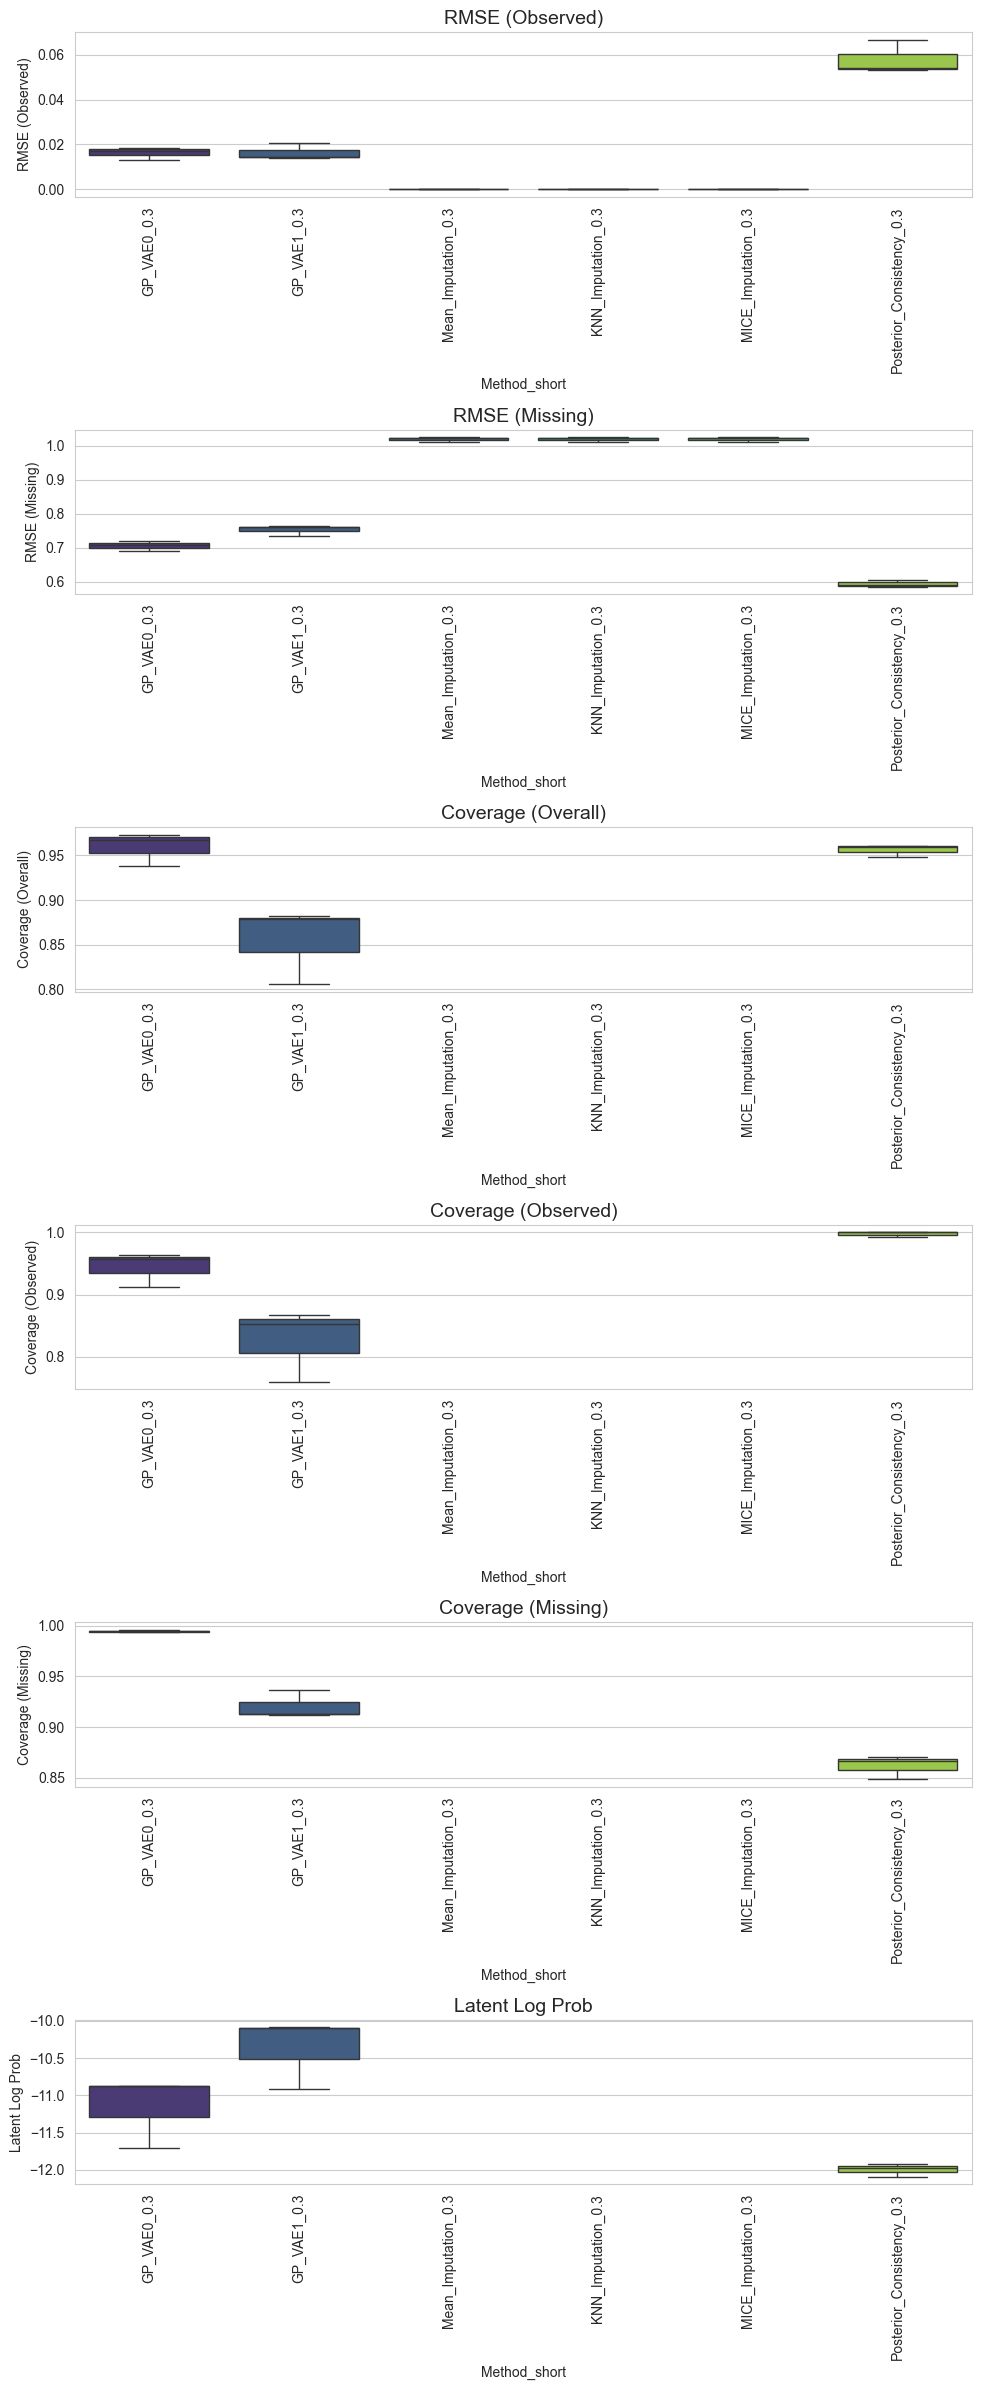

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

p = '0.3'

# Define metrics to plot
metrics_to_plot = [
    "RMSE (Observed)", 
    "RMSE (Missing)",
    "Coverage (Overall)", 
    "Coverage (Observed)", 
    "Coverage (Missing)",
    "Latent Log Prob"
]

# Use Seaborn style
sns.set_style("whitegrid")

# Create subplots
num_metrics = len(metrics_to_plot)
fig, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, num_metrics * 4))

# Plot each metric
for i, metric in enumerate(metrics_to_plot):
    ax = axes[i] if num_metrics > 1 else axes  # Handle single subplot case
    
    # Sort methods for consistent plotting
    sorted_methods = df[df.p == p]["Method_short"].unique()
    
    # Bar plot with 'hue' to avoid warnings
    sns.boxplot(data=df[df.p == p], x="Method_short", y=metric, ax=ax, hue="Method_short", dodge=False, legend=False, palette="viridis")
    
    ax.set_title(metric, fontsize=14)
    ax.set_ylabel(metric)
    #ax.set_yscale('log')
    
    # Fix x-tick formatting issue
    ax.set_xticks(range(len(sorted_methods)))  
    ax.set_xticklabels(sorted_methods, rotation=90)

plt.tight_layout()
plt.show()


/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_65646/4252785581.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df.p == '0.3'], x="Method_short", y=metric, ax=ax, palette="viridis")
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_65646/4252785581.py:25: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Rotate labels for better visibility
/var/folders/7s/75p3d4f145qfrrzfq5vskssc0000gn/T/ipykernel_65646/4252785581.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df.p == '0.3'], x="Method_short", y=metric, ax=ax, palette="viridis")
/var/folders/7s/75p3d4f145qfrrz

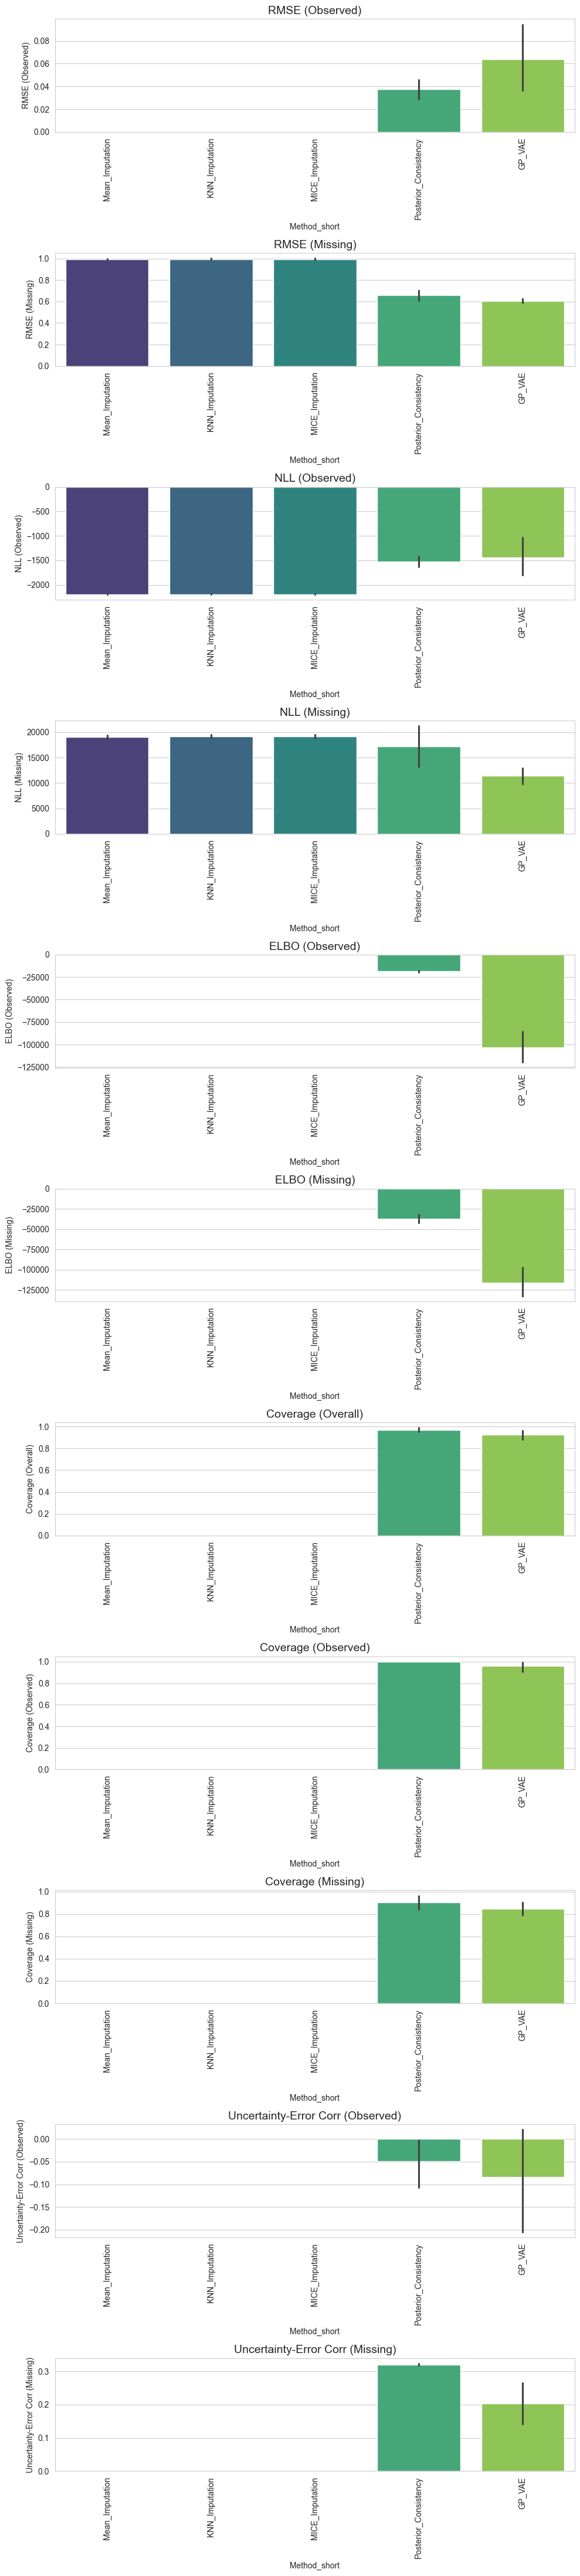

In [67]:
# Convert "Method" column into a categorical type for better plotting
df["Method"] = df["Method"].astype(str)

# Define the metrics to plot
metrics_to_plot = [
    "RMSE (Observed)", "RMSE (Missing)", 
    "NLL (Observed)", "NLL (Missing)", 
    "ELBO (Observed)", "ELBO (Missing)",
    "Coverage (Overall)", "Coverage (Observed)", "Coverage (Missing)",
    "Uncertainty-Error Corr (Observed)", "Uncertainty-Error Corr (Missing)"
]

# Create subplots for each metric
num_metrics = len(metrics_to_plot)
fig, axes = plt.subplots(nrows=num_metrics, ncols=1, figsize=(10, num_metrics * 4))

# Use seaborn style for better visualization
sns.set_style("whitegrid")

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i] if num_metrics > 1 else axes  # Handle single subplot case
    ax.set_yscale = 'log'
    sns.barplot(data=df[df.p == '0.3'], x="Method_short", y=metric, ax=ax, palette="viridis")
    ax.set_title(metric, fontsize=14)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)  # Rotate labels for better visibility
    ax.set_ylabel(metric)

plt.tight_layout()
plt.show()


<Axes: >

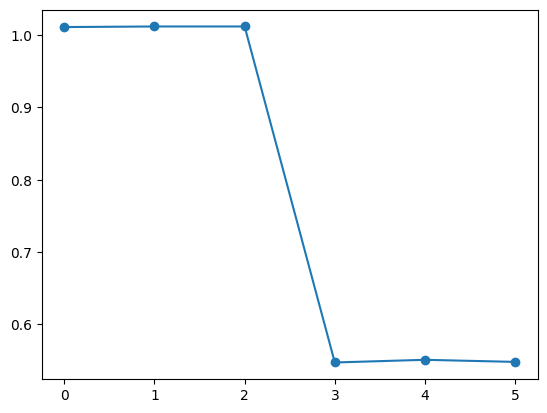

In [17]:
df[df.p == '0.1']['RMSE (Missing)'].plot(marker = 'o')

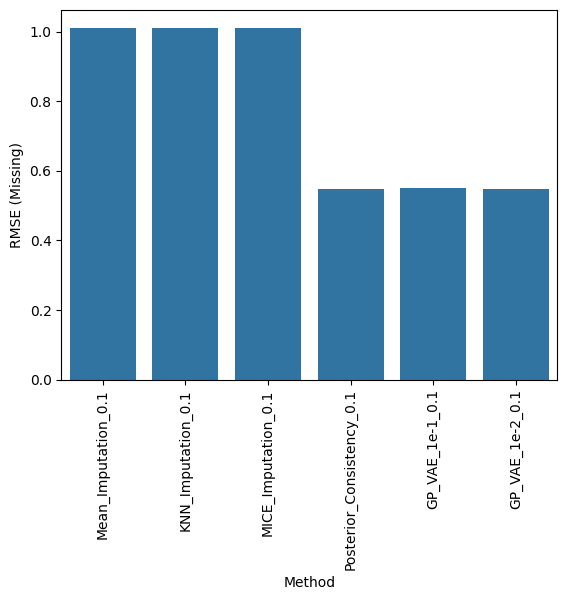

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(df[df.p == '0.1'], y = 'RMSE (Missing)', x= 'Method')
plt.xticks(rotation = 90);